# 14｜seed bagging 收尾 vs notebook 11 的 6214

**目的**：把「同配方 5 个 seed、先平均 96 点曲线再 `optimize_day`」写成冻结部署协议。对标的是 notebook 11 的失败（v2 Transformer **6214.36** / capture **0.690**），不是 oracle 9001。

**预先锁死的 headline：** `listwise_transformer_mean`。这是 Claude B 轨用 30 日日均 capture 选出的 listwise Transformer（`tau_tgt=0.05`，网格最尖，**更尖的 12 窗 CE**），不是 59 日上挑出来的冠军。另外两袋（SPO+ LSTM、nb12 窗 CE LSTM）和窗投票、50/50 只作对照/消融；holdout 更高也不改 headline。

**59 日均值 SE ≈ 550**，分辨不了 ±200–400。三条袋之间**不排序**。不改 Phase B 冻结数，不改 v1/v2 的 RMSE/MAE 列。


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from matplotlib import font_manager


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'phase_b').is_dir():
            return candidate
    raise FileNotFoundError('请从 Southern_Electricity 仓库内启动 notebook')


def show_figure(path: Path) -> None:
    display(Image(filename=str(path)))


_cjk = next(
    (name for name in ('Microsoft YaHei', 'SimHei', 'Microsoft JhengHei')
     if any(font.name == name for font in font_manager.fontManager.ttflist)),
    None,
)
if _cjk:
    plt.rcParams['font.sans-serif'] = [_cjk, 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

REPO_ROOT = find_repo_root()
os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.matplotlib_cache'))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES = REPO_ROOT / 'outputs' / 'notebooks' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
REPORT = REPO_ROOT / 'reports' / 'holdout_seed_bag_v1'
V2 = REPO_ROOT / 'reports' / 'holdout_rmse_v2'
NB12 = REPO_ROOT / 'reports' / 'holdout_dispatch_loss_v1'
NB13 = REPO_ROOT / 'reports' / 'holdout_dfl_bakeoff_v1'
CLAUDE = REPO_ROOT / 'reports' / 'holdout_dfl_ltr_v1'
PHASE_B = REPO_ROOT / 'reports' / 'phase_b' / 'final_metrics.json'
MONEY_LINE = 6214.361782
HOLD_SE = 550.0
HEADLINE = 'listwise_transformer_mean'
assert PHASE_B.exists(), 'phase_b frozen metrics must still be present'
assert (REPORT / 'leaderboard.csv').exists(), '先跑 python -m experiments.holdout_seed_bag_v1.run'
print({'repo_root': str(REPO_ROOT), 'report': str(REPORT.relative_to(REPO_ROOT))})


{'repo_root': '<repo>', 'report': 'reports\\holdout_seed_bag_v1'}


In [2]:
manifest = json.loads((REPORT / 'manifest.json').read_text(encoding='utf-8'))
board = pd.read_csv(REPORT / 'leaderboard.csv')
daily = pd.read_csv(REPORT / 'dispatch_daily.csv')
daily['date'] = pd.to_datetime(daily['date'], format='mixed').dt.normalize()
assert manifest['holdout_not_used_for_selection'] is True
assert manifest['headline_bag'] == 'listwise_transformer'
assert manifest['money_line_source'].startswith('nb11')

v2_daily = pd.read_csv(V2 / 'dispatch_daily.csv')
v2_daily['date'] = pd.to_datetime(v2_daily['date'], format='mixed').dt.normalize()
nb11 = v2_daily.loc[v2_daily['model'] == 'transformer_contextual', 'realized_profit']
nb11_mean = float(nb11.mean())
assert abs(nb11_mean - MONEY_LINE) < 1e-3

nb12_board = pd.read_csv(NB12 / 'leaderboard.csv')
lstm12 = float(nb12_board.loc[nb12_board['model'] == 'lstm_dispatch', 'realized_profit_mean'].iloc[0])
spo13 = float('nan')
if (NB13 / 'leaderboard.csv').exists():
    b13 = pd.read_csv(NB13 / 'leaderboard.csv')
    if 'lstm_spoplus' in set(b13['model']):
        spo13 = float(b13.loc[b13['model'] == 'lstm_spoplus', 'realized_profit_mean'].iloc[0])

head = board.loc[board['model'] == HEADLINE].iloc[0]
print(board.loc[board['combiner'].isin(['curve_mean', 'curve_mean_two_bags', 'window_vote']),
                ['model', 'combiner', 'headline', 'realized_profit_mean', 'capture', 'seed_realized_min', 'seed_realized_max']
               ].to_string(index=False))


                    model            combiner  headline  realized_profit_mean  capture  seed_realized_min  seed_realized_max
listwise_transformer_mean          curve_mean      True           6693.875025 0.743691        6257.761327        6551.772867
listwise_transformer_vote         window_vote     False           6709.620663 0.745440        6257.761327        6551.772867
            spo_lstm_mean          curve_mean     False           6476.013318 0.719486        6239.067160        6546.560556
            spo_lstm_vote         window_vote     False           6439.635254 0.715445        6239.067160        6546.560556
      window_ce_lstm_mean          curve_mean     False           6114.310487 0.679301        5699.286683        6301.350028
      window_ce_lstm_vote         window_vote     False           6043.379274 0.671420        5699.286683        6301.350028
       listwise_spo_50_50 curve_mean_two_bags     False           6537.144210 0.726278                NaN                NaN


In [3]:
def se_mean(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors='coerce').dropna()
    return float(s.std(ddof=1) / np.sqrt(len(s)))

head_days = daily.loc[daily['model'] == HEADLINE].sort_values('date')
nb11_days = v2_daily.loc[v2_daily['model'] == 'transformer_contextual'].sort_values('date')
aligned = pd.merge(
    nb11_days[['date', 'realized_profit']].rename(columns={'realized_profit': 'nb11'}),
    head_days[['date', 'realized_profit']].rename(columns={'realized_profit': 'head'}),
    on='date',
)
delta = aligned['head'] - aligned['nb11']
without_1230 = aligned.loc[aligned['date'] != pd.Timestamp('2025-12-30')]
d1230 = aligned.loc[aligned['date'] == pd.Timestamp('2025-12-30')]

head_realized = float(head['realized_profit_mean'])
passed = head_realized > MONEY_LINE
lift = head_realized - MONEY_LINE
emp_se = se_mean(head_days['realized_profit'])

bag_means = board.loc[board['combiner'] == 'curve_mean'].copy()
spread = float(bag_means['realized_profit_mean'].max() - bag_means['realized_profit_mean'].min())

lines = []
if passed:
    lines.append(
        f"**过线。** 预先指定的 headline `{HEADLINE}` 59 日 realized **{head_realized:.0f}**，"
        f"相对 notebook 11 的 6214 为 **{lift:+.0f}**（capture {float(head['capture']):.3f}）。"
    )
else:
    lines.append(
        f"**未过线。** headline `{HEADLINE}` realized **{head_realized:.0f}**，通过线是 6214。"
    )
lines.append(
    f"这是 **更尖的 12 窗 CE**（`tau_tgt=0.05`）× Transformer × 5 seed **曲线平均**，不是新损失冠军，也不是 59 日上挑出来的第一名。"
)
lines.append(
    f"经验 SE（headline 日序列）**{emp_se:.0f}**，计划里用的约 **{HOLD_SE:.0f}**。三条曲线平均袋的分差 {spread:.0f}，仍在 SE 量级内；**59 天分不清哪一袋更好**，不做排名，也不因 holdout 高低改 headline。"
)
if len(d1230):
    lines.append(
        f"12-30 当天 headline {float(d1230['head'].iloc[0]):.0f} vs 11 的 {float(d1230['nb11'].iloc[0]):.0f}；"
        f"去掉这天相对 11 的日均差 {float((without_1230['head']-without_1230['nb11']).mean()):+.0f}。"
    )
ce_bag = board.loc[board['model'] == 'window_ce_lstm_mean']
if len(ce_bag) and float(ce_bag['realized_profit_mean'].iloc[0]) > MONEY_LINE:
    lines.append(
        f"窗 CE LSTM 袋 realized **{float(ce_bag['realized_profit_mean'].iloc[0]):.0f}** 也过了 6214："
        "单是把 12 做 5 seed 平均就已经好于 11，不能把涨分全记在 listwise 上。"
    )
lines.append(
    f"对照：nb12 单 seed LSTM {lstm12:.0f}；nb13 SPO+ LSTM {spo13:.0f}。"
    "59 天不是新冠军；Phase B 与 v1/v2 RMSE 列未动。"
)
display(Markdown('### 核心结案（由产物计算）\n\n' + '\n\n'.join('- ' + s for s in lines)))


### 核心结案（由产物计算）

- **过线。** 预先指定的 headline `listwise_transformer_mean` 59 日 realized **6694**，相对 notebook 11 的 6214 为 **+480**（capture 0.744）。

- 这是 **更尖的 12 窗 CE**（`tau_tgt=0.05`）× Transformer × 5 seed **曲线平均**，不是新损失冠军，也不是 59 日上挑出来的第一名。

- 经验 SE（headline 日序列）**613**，计划里用的约 **550**。三条曲线平均袋的分差 580，仍在 SE 量级内；**59 天分不清哪一袋更好**，不做排名，也不因 holdout 高低改 headline。

- 12-30 当天 headline 27837 vs 11 的 3499；去掉这天相对 11 的日均差 +68。

- 对照：nb12 单 seed LSTM 6301；nb13 SPO+ LSTM 6410。59 天不是新冠军；Phase B 与 v1/v2 RMSE 列未动。

## 主表：对 6214，三条袋不排名

RMSE 只在附录。Headline 行不随 holdout 高低改写。


In [4]:
rows = [
    {'配方': 'nb11 v2 Transformer（钱冠）', '口径': '单 seed 点 RMSE', 'realized': nb11_mean, 'capture': nb11_mean / 9000.886096, 'vs 6214': 0.0, 'headline': False},
    {'配方': 'nb12 lstm_dispatch', '口径': '单 seed 窗 CE', 'realized': lstm12, 'capture': lstm12 / 9000.886096, 'vs 6214': lstm12 - MONEY_LINE, 'headline': False},
]
if np.isfinite(spo13):
    rows.append({'配方': 'nb13 lstm_spoplus', '口径': '单 seed SPO+', 'realized': spo13, 'capture': spo13 / 9000.886096, 'vs 6214': spo13 - MONEY_LINE, 'headline': False})
for _, r in board.loc[board['combiner'] == 'curve_mean'].iterrows():
    rows.append({
        '配方': r['model'],
        '口径': '5 seed 曲线平均',
        'realized': r['realized_profit_mean'],
        'capture': r['capture'],
        'vs 6214': r['realized_profit_mean'] - MONEY_LINE,
        'headline': bool(r['headline']),
    })
mix = board.loc[board['model'] == 'listwise_spo_50_50']
if len(mix):
    r = mix.iloc[0]
    rows.append({'配方': r['model'], '口径': '消融：两袋 50/50', 'realized': r['realized_profit_mean'], 'capture': r['capture'], 'vs 6214': r['realized_profit_mean'] - MONEY_LINE, 'headline': False})
TAB = pd.DataFrame(rows)
TAB['过 6214'] = TAB['realized'] > MONEY_LINE
display(TAB.style.format({'realized': '{:.1f}', 'capture': '{:.3f}', 'vs 6214': '{:+.1f}'}))

spread_tab = board.loc[board['combiner'] == 'curve_mean', ['model', 'seed_realized_min', 'seed_realized_max', 'realized_profit_mean']].copy()
spread_tab = spread_tab.rename(columns={'realized_profit_mean': '五条平均后再锁窗', 'seed_realized_min': '单 seed 最低', 'seed_realized_max': '单 seed 最高'})
display(Markdown('袋内 min / max / 平均（平均的是曲线，不是把每天分数再平均）：'))
display(spread_tab.style.format('{:.1f}', subset=['单 seed 最低', '单 seed 最高', '五条平均后再锁窗']))


,配方,口径,realized,capture,vs 6214,headline,过 6214
0,nb11 v2 Transformer（钱冠）,单 seed 点 RMSE,6214.4,0.690,+0.0,False,False
1,nb12 lstm_dispatch,单 seed 窗 CE,6301.3,0.700,+87.0,False,True
2,nb13 lstm_spoplus,单 seed SPO+,6410.0,0.712,+195.6,False,True
3,listwise_transformer_mean,5 seed 曲线平均,6693.9,0.744,+479.5,True,True
4,spo_lstm_mean,5 seed 曲线平均,6476.0,0.719,+261.7,False,True
5,window_ce_lstm_mean,5 seed 曲线平均,6114.3,0.679,-100.1,False,False
6,listwise_spo_50_50,消融：两袋 50/50,6537.1,0.726,+322.8,False,True


袋内 min / max / 平均（平均的是曲线，不是把每天分数再平均）：

,model,单 seed 最低,单 seed 最高,五条平均后再锁窗
0,listwise_transformer_mean,6257.8,6551.8,6693.9
7,spo_lstm_mean,6239.1,6546.6,6476.0
14,window_ce_lstm_mean,5699.3,6301.4,6114.3


outputs\notebooks\figures\nb14_vs_6214.png


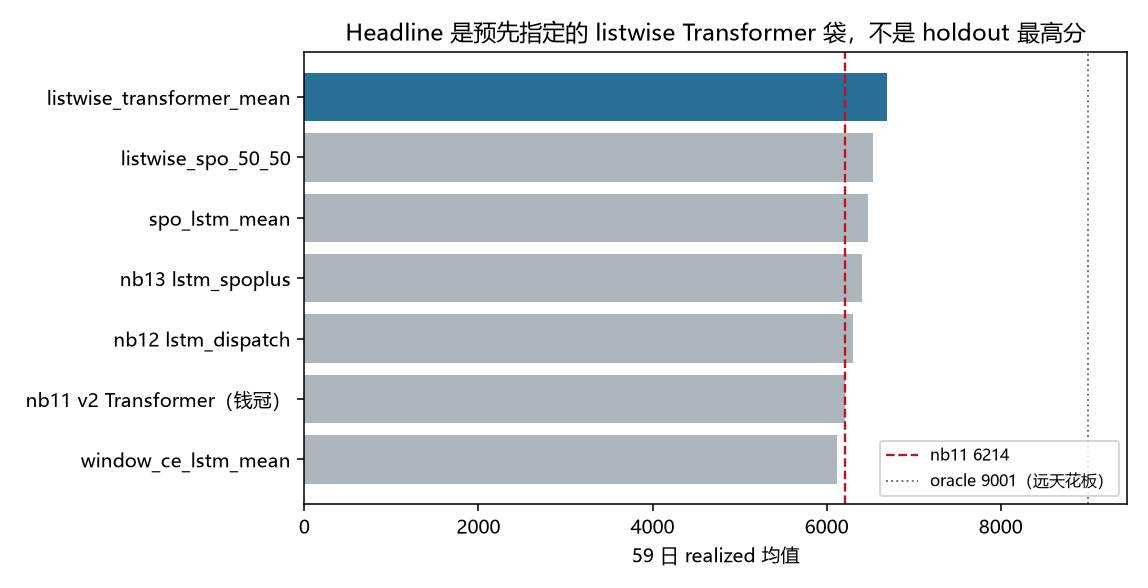

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
plot = TAB.sort_values('realized')
colors = ['#2a6f97' if h else '#adb5bd' for h in plot['headline']]
ax.barh(plot['配方'], plot['realized'], color=colors)
ax.axvline(MONEY_LINE, color='#c1121f', ls='--', lw=1.2, label='nb11 6214')
ax.axvline(9000.886, color='#6c757d', ls=':', lw=1, label='oracle 9001（远天花板）')
ax.set_xlabel('59 日 realized 均值')
ax.set_title('Headline 是预先指定的 listwise Transformer 袋，不是 holdout 最高分')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
p1 = FIGURES / 'nb14_vs_6214.png'
fig.savefig(p1, dpi=140)
plt.close()
print(p1.relative_to(REPO_ROOT))
show_figure(p1)


outputs\notebooks\figures\nb14_seed_span.png


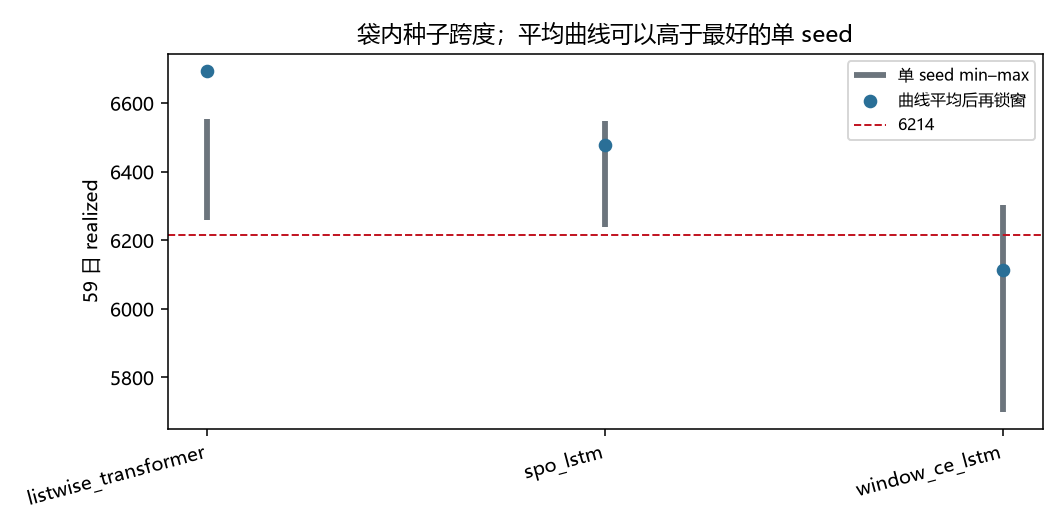

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
labels, mins, maxs, means = [], [], [], []
for _, r in board.loc[board['combiner'] == 'curve_mean'].iterrows():
    labels.append(r['model'].replace('_mean', ''))
    mins.append(r['seed_realized_min'])
    maxs.append(r['seed_realized_max'])
    means.append(r['realized_profit_mean'])
x = np.arange(len(labels))
ax.vlines(x, mins, maxs, color='#6c757d', lw=3, label='单 seed min–max')
ax.scatter(x, means, color='#2a6f97', zorder=3, label='曲线平均后再锁窗')
ax.axhline(MONEY_LINE, color='#c1121f', ls='--', lw=1, label='6214')
ax.set_xticks(x, labels, rotation=15, ha='right')
ax.set_ylabel('59 日 realized')
ax.set_title('袋内种子跨度；平均曲线可以高于最好的单 seed')
ax.legend(fontsize=8)
fig.tight_layout()
p2 = FIGURES / 'nb14_seed_span.png'
fig.savefig(p2, dpi=140)
plt.close()
print(p2.relative_to(REPO_ROOT))
show_figure(p2)


outputs\notebooks\figures\nb14_daily_vs_11.png

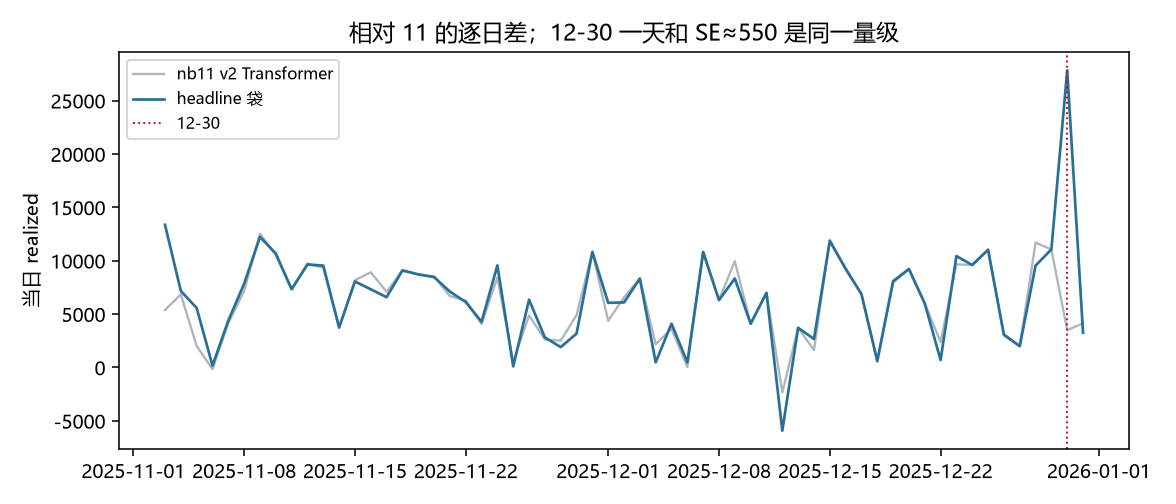

配对日均差 +479.5；经验 SE 452。去掉 12-30 之后 +68.2。

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))
cmp = aligned.sort_values('date')
ax.plot(cmp['date'], cmp['nb11'], label='nb11 v2 Transformer', color='#adb5bd', lw=1.2)
ax.plot(cmp['date'], cmp['head'], label='headline 袋', color='#2a6f97', lw=1.4)
if (cmp['date'] == pd.Timestamp('2025-12-30')).any():
    ax.axvline(pd.Timestamp('2025-12-30'), color='#c1121f', ls=':', lw=1, label='12-30')
ax.set_ylabel('当日 realized')
ax.set_title('相对 11 的逐日差；12-30 一天和 SE≈550 是同一量级')
ax.legend(fontsize=8)
fig.tight_layout()
p3 = FIGURES / 'nb14_daily_vs_11.png'
fig.savefig(p3, dpi=140)
plt.close()
print(p3.relative_to(REPO_ROOT))
show_figure(p3)
display(Markdown(
    f"配对日均差 {float(delta.mean()):+.1f}；经验 SE {float(delta.std(ddof=1)/np.sqrt(len(delta))):.0f}。"
    f"去掉 12-30 之后 {float((without_1230['head']-without_1230['nb11']).mean()):+.1f}。"
))


## 附录：窗投票消融与 RMSE

窗投票若 holdout 更高，也不替换 headline。RMSE 不是通过标准。


In [8]:
app = board.loc[board['combiner'].isin(['curve_mean', 'window_vote', 'curve_mean_two_bags']),
                ['model', 'combiner', 'headline', 'realized_profit_mean', 'capture', 'RMSE', 'pred_profit_mean']].copy()
display(app.style.format({'realized_profit_mean': '{:.1f}', 'capture': '{:.3f}', 'RMSE': '{:.3f}', 'pred_profit_mean': '{:.1f}'}))
print('manifest seconds', manifest.get('seconds_total'), 'phase_b exists', PHASE_B.exists())
print('headline beats 6214', bool(head['beats_nb11_6214']))


,model,combiner,headline,realized_profit_mean,capture,RMSE,pred_profit_mean
0,listwise_transformer_mean,curve_mean,True,6693.9,0.744,0.767,4778.1
1,listwise_transformer_vote,window_vote,False,6709.6,0.745,0.767,4776.8
7,spo_lstm_mean,curve_mean,False,6476.0,0.719,0.841,7343.0
8,spo_lstm_vote,window_vote,False,6439.6,0.715,0.841,7338.1
14,window_ce_lstm_mean,curve_mean,False,6114.3,0.679,0.835,6589.9
15,window_ce_lstm_vote,window_vote,False,6043.4,0.671,0.835,6581.4
21,listwise_spo_50_50,curve_mean_two_bags,False,6537.1,0.726,0.789,6032.4


manifest seconds 81.4 phase_b exists True
headline beats 6214 True
